In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from matplotlib.colors import ListedColormap

iris = datasets.load_iris()
X = iris.data
y = iris.target

In [3]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

In [5]:
clf1 = LogisticRegression(random_state=42, solver='saga')
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = KNeighborsClassifier()

voting_clf = VotingClassifier(
    estimators=[
        ('lr', clf1),
        ('dt', clf2),
        ('knn', clf3)
    ],
    voting='soft'  # 可以切换'hard'
)

In [6]:
for clf, label in zip([clf1, clf2, clf3, voting_clf],
                      ['Logistic Regression', 'Decision Tree', 'KNN', 'Voting']):
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{label} Accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")

Logistic Regression Accuracy: 0.94 (+/- 0.05)
Decision Tree Accuracy: 0.94 (+/- 0.06)
KNN Accuracy: 0.96 (+/- 0.04)
Voting Accuracy: 0.95 (+/- 0.06)


In [7]:
voting_clf.fit(X_train, y_train)
print("Voting Classifier Test Accuracy:", voting_clf.score(X_test, y_test))  # 所有监督模型都支持.score()只是之前没出现过

Voting Classifier Test Accuracy: 1.0


In [8]:
params = {
    'weights': [[w1, w2, w3] for w1 in range(1, 5) for w2 in range(1, 5) for w3 in range(1, 5)],
}

grid = GridSearchCV(estimator=voting_clf, param_grid=params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best Weights:", grid.best_params_['weights'])
print("Best Cross-Validated Accuracy:", grid.best_score_)

Best Weights: [1, 2, 3]
Best Cross-Validated Accuracy: 0.9619047619047618


In [9]:
voting_clf_opt = VotingClassifier(estimators=[
    ('lr', clf1),
    ('dt', clf2),
    ('knn', clf3)
], voting='soft', weights=grid.best_params_['weights'])
voting_clf_opt.fit(X_train, y_train)
print("Optimized Voting Classifier Test Accuracy:", voting_clf_opt.score(X_test, y_test))

Optimized Voting Classifier Test Accuracy: 1.0


In [10]:
def plot_decision_boundary(clf, X, y, title):
    # 定义网格范围
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 预测网格中的每个点
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 颜色映射
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor='k', cmap=cmap_bold)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.show()

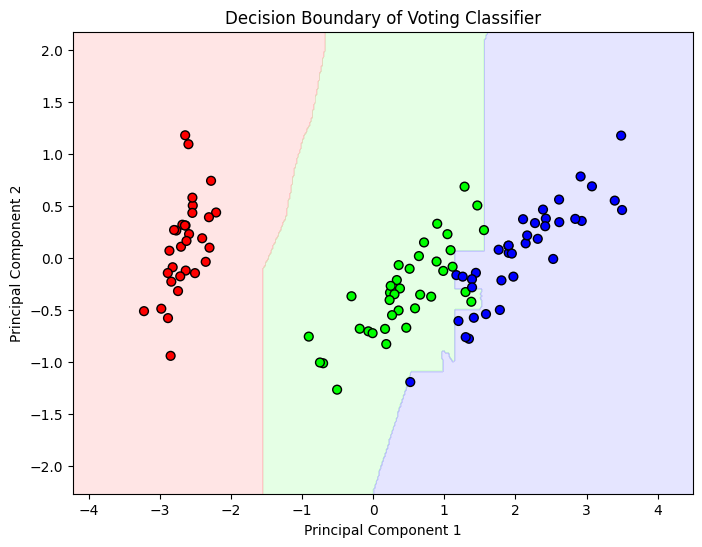

In [11]:
plot_decision_boundary(voting_clf, X_train, y_train, "Decision Boundary of Voting Classifier")

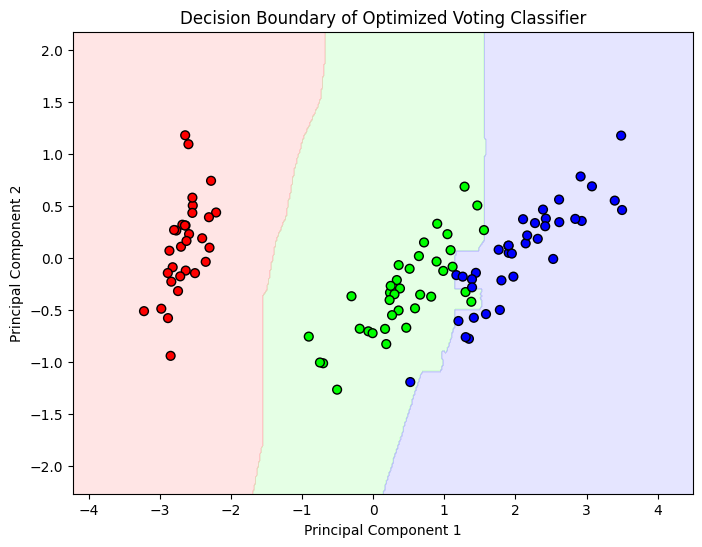

In [12]:
plot_decision_boundary(voting_clf_opt, X_train, y_train, "Decision Boundary of Optimized Voting Classifier")